# Section 1 - Data Fundamentals

In [96]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Renders charts directly inside the notebook (Jupyter-specific command)
%matplotlib inline

# ── Configuration constants ───────────────────────────────────────────────────
TICKER: str     = "AAPL"
START_DATE: str = "2018-01-01"
END_DATE: str   = "2023-12-31"

In [97]:
import sys 
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates

%matplotlib inline

TICKER2: str = "SAN"  # the :str is industry standard to let people ready code knows what i am doing
START_DATE2: str = "2019-01-01"
END_DATE2: str = "2022-12-31"

In [98]:
# APPL

def fetch_price_data(ticker: str, start: str, end: str) -> pd.DataFrame:
      """
      Download adjusted OHLCV data from Yahoo Finance for a given ticker.

      Parameters
      ----------
      ticker : str
          The stock ticker symbol, e.g. "AAPL" for Apple.
      start : str
          Start date string in "YYYY-MM-DD" format (inclusive).
      end : str
          End date string in "YYYY-MM-DD" format (inclusive).

      Returns
      -------
      pd.DataFrame
          A DataFrame indexed by date with OHLCV + Adjusted Close columns.
      """
      print(f"[INFO] Fetching data for {ticker} from {start} to {end} ...")

      raw: pd.DataFrame = yf.download(
          tickers=ticker,
          start=start,
          end=end,
          auto_adjust=False,  # Keep separate 'Close' and 'Adj Close' columns
          progress=False,
      )

      if raw.empty:
          print(f"[ERROR] No data returned for '{ticker}'. Check the symbol.")
          sys.exit(1)

      print(f"[INFO] Downloaded {len(raw):,} trading days of data.")
      return raw


  # ── Run it ────────────────────────────────────────────────────────────────────
raw_df: pd.DataFrame = fetch_price_data(TICKER, START_DATE, END_DATE)


[INFO] Fetching data for AAPL from 2018-01-01 to 2023-12-31 ...
[INFO] Downloaded 1,509 trading days of data.


In [99]:
def fetch_price_data_san(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    this is also an industry standard where you explain what is the function goind to do the 
    parameters and what the return is going to be 
    """
    print(f"[INFO] Fecthes data fro {ticker} from {start_date} to {end_date}")

    raw_san: pd.DataFrame = yf.download(  
        tickers=ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False, # this make sure that we get both closes 
        progress=False, # this make sure that we don't see the what the program is doing
    )

    if raw_san.empty:
        print(f"[ERROR] no data in {ticker}")
        sys.exit(1) # stops the program if file is empty
    
    print(f"[INFO] Downloaded {len(raw_san):,} trading days of data.")
    return raw_san

raw_san_df: pd.DataFrame = fetch_price_data_san(TICKER2, START_DATE2, END_DATE2)

[INFO] Fecthes data fro SAN from 2019-01-01 to 2022-12-31
[INFO] Downloaded 1,008 trading days of data.


In [100]:
# APPL

def inspect_dataframe(df: pd.DataFrame, ticker: str) -> None:
      """
      Print a structured inspection of the raw DataFrame.
      Covers shape, date range, column types, sample rows, and summary stats.

      Parameters
      ----------
      df : pd.DataFrame
          The raw price DataFrame returned by fetch_price_data().
      ticker : str
          Ticker symbol used for display labels.
      """
      print("=" * 60)
      print(f"  DATA INSPECTION — {ticker}")
      print("=" * 60)

      rows, cols = df.shape
      print(f"\n  Shape       : {rows:,} rows × {cols} columns")
      print(f"  Date range  : {df.index.min().date()} → {df.index.max().date()}")

      print(f"\n  Columns and dtypes:")
      for col, dtype in df.dtypes.items():
          print(f"    {str(col):<25} {dtype}")

      print(f"\n  First 5 rows:")
      display(df.head())          # display() renders a clean HTML table in Jupyter

      print(f"\n  Last 5 rows:")
      display(df.tail())

      print(f"\n  Summary statistics:")
      display(df.describe().round(2))


  # ── Run it ────────────────────────────────────────────────────────────────────
inspect_dataframe(raw_df, TICKER)

  DATA INSPECTION — AAPL

  Shape       : 1,509 rows × 6 columns
  Date range  : 2018-01-02 → 2023-12-29

  Columns and dtypes:
    ('Adj Close', 'AAPL')     float64
    ('Close', 'AAPL')         float64
    ('High', 'AAPL')          float64
    ('Low', 'AAPL')           float64
    ('Open', 'AAPL')          float64
    ('Volume', 'AAPL')        int64

  First 5 rows:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-01-02,40.304176,43.064999,43.075001,42.314999,42.540001,102223600
2018-01-03,40.297161,43.057499,43.637501,42.990002,43.132500,118071600
2018-01-04,40.484337,43.257500,43.367500,43.020000,43.134998,89738400
2018-01-05,40.945274,43.750000,43.842499,43.262501,43.360001,94640000
2018-01-08,40.793179,43.587502,43.902500,43.482498,43.587502,82271200



  Last 5 rows:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2023-12-22,191.609482,193.600006,195.410004,192.970001,195.179993,37149600
2023-12-26,191.065109,193.050003,193.889999,192.830002,193.610001,28919300
2023-12-27,191.164093,193.149994,193.500000,191.089996,192.490005,48087700
2023-12-28,191.589661,193.580002,194.660004,193.169998,194.139999,34049900
2023-12-29,190.550476,192.529999,194.399994,191.729996,193.899994,42672100



  Summary statistics:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1509.00,1509.00,1509.00,1509.00,1509.00,1.509000e+03
mean,107.72,110.43,111.58,109.16,110.33,1.073284e+08
std,50.89,51.04,51.52,50.51,51.00,5.513287e+07
min,33.77,35.55,36.43,35.50,35.99,2.404830e+07
25%,51.19,53.87,54.79,53.29,54.10,7.078370e+07
50%,120.35,123.54,124.98,122.14,123.66,9.296430e+07
75%,150.08,152.74,154.56,150.80,152.57,1.280440e+08
max,196.07,198.11,199.62,197.00,198.02,4.265100e+08


In [101]:
def data_inspection_san(df: pd.DataFrame, ticker: str) -> None:

    print("="*60)
    print(f"DATA INSPECTION - {ticker}")
    print("="*60)

    rows, cols = df.shape
    print(f"\n  Shape: there are {rows:,} rows and {cols:,}")
    print(f"\n  Data range: from {df.index.min().date()} to {df.index.max().date()}")

    print(f"\n  Data types:")
    for cols, dtypes in df.dtypes.items():
        print(f"     {str(cols):<25} {dtypes}")

    print(f"\n First 5 rows")
    display(df.head())

    print(f"\n Last 5 rows")
    display(df.tail())

    print(f"\n Summary statistics")
    display(df.describe().round(2))

data_inspection_san(raw_san_df, TICKER2)

DATA INSPECTION - SAN

  Shape: there are 1,008 rows and 6

  Data range: from 2019-01-02 to 2022-12-30

  Data types:
     ('Adj Close', 'SAN')      float64
     ('Close', 'SAN')          float64
     ('High', 'SAN')           float64
     ('Low', 'SAN')            float64
     ('Open', 'SAN')           float64
     ('Volume', 'SAN')         int64

 First 5 rows


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SAN,SAN,SAN,SAN,SAN,SAN
Date,,,,,,
2019-01-02,3.617105,4.51,4.53,4.40,4.40,8905500
2019-01-03,3.649187,4.55,4.58,4.52,4.55,6186700
2019-01-04,3.785529,4.72,4.75,4.68,4.70,6432200
2019-01-07,3.833651,4.78,4.82,4.73,4.75,6737000
2019-01-08,3.857710,4.81,4.84,4.78,4.83,4158600



 Last 5 rows


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SAN,SAN,SAN,SAN,SAN,SAN
Date,,,,,,
2022-12-23,2.656702,2.94,2.95,2.92,2.95,3062500
2022-12-27,2.665738,2.95,2.98,2.95,2.95,2999400
2022-12-28,2.647666,2.93,2.98,2.93,2.96,1622600
2022-12-29,2.692847,2.98,2.99,2.96,2.96,2377600
2022-12-30,2.665738,2.95,2.99,2.95,2.96,3397200



 Summary statistics


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SAN,SAN,SAN,SAN,SAN,SAN
count,1008.00,1008.00,1008.00,1008.00,1008.00,1008.00
mean,2.89,3.41,3.44,3.37,3.41,7768534.23
std,0.66,0.83,0.83,0.83,0.83,5143922.90
min,1.52,1.79,1.84,1.78,1.80,1622600.00
25%,2.36,2.67,2.70,2.64,2.65,4596300.00
50%,2.98,3.47,3.50,3.44,3.47,6490250.00
75%,3.37,3.98,4.01,3.95,3.99,9061725.00
max,4.25,5.22,5.25,5.18,5.24,50237500.00


In [102]:
# APPL

def check_data_quality(df: pd.DataFrame) -> pd.DataFrame:
      """
      Identify and handle data quality issues in the raw price DataFrame.

      Checks:
        1. Missing values (NaN)  → forward-filled
        2. Zero-volume days      → dropped
        3. Duplicate date rows   → deduplicated (keep first)

      Parameters
      ----------
      df : pd.DataFrame
          The raw price DataFrame.

      Returns
      -------
      pd.DataFrame
          A cleaned DataFrame ready for analysis.
      """
      print("=" * 60)
      print("  DATA QUALITY REPORT")
      print("=" * 60)

      # Check 1: Missing values
      missing: pd.Series = df.isnull().sum()
      total_missing: int = int(missing.sum())

      if total_missing == 0:
          print("\n  [PASS] No missing values found.")
      else:
          print(f"\n  [WARN] Missing values detected:")
          print(missing[missing > 0].to_string())
          df = df.ffill()
          print("  [FIX]  Applied forward-fill.")

      # Check 2: Zero-volume days
      vol_col = [c for c in df.columns if "Volume" in str(c)][0]
      zero_vol_days: int = int((df[vol_col] == 0).sum())

      if zero_vol_days == 0:
          print("  [PASS] No zero-volume days found.")
      else:
          print(f"\n  [WARN] {zero_vol_days} zero-volume day(s) found. Dropping.")
          df = df[df[vol_col] != 0]

      # Check 3: Duplicate dates
      duplicate_dates: int = int(df.index.duplicated().sum())

      if duplicate_dates == 0:
          print("  [PASS] No duplicate dates found.")
      else:
          print(f"\n  [WARN] {duplicate_dates} duplicate date(s). Keeping first.")
          df = df[~df.index.duplicated(keep="first")]

      df = df.sort_index()
      print(f"\n  [INFO] Clean dataset: {len(df):,} trading days remaining.")
      return df


def flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
      """
      Flatten yfinance MultiIndex columns (e.g. ('Close', 'AAPL')) to
      simple single-level names (e.g. 'Close').

      Parameters
      ----------
      df : pd.DataFrame
          DataFrame with MultiIndex columns from yfinance.

      Returns
      -------
      pd.DataFrame
          DataFrame with simple, single-level column names.
      """
      if isinstance(df.columns, pd.MultiIndex):
          df.columns = [col[0] for col in df.columns]
      return df


  # ── Run it ────────────────────────────────────────────────────────────────────
clean_df: pd.DataFrame = check_data_quality(raw_df)
clean_df = flatten_columns(clean_df)
print(f"\n  Columns after flattening: ")
display(clean_df.head())

  DATA QUALITY REPORT

  [PASS] No missing values found.
  [PASS] No zero-volume days found.
  [PASS] No duplicate dates found.

  [INFO] Clean dataset: 1,509 trading days remaining.

  Columns after flattening: 


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-02,40.304176,43.064999,43.075001,42.314999,42.540001,102223600
2018-01-03,40.297161,43.057499,43.637501,42.990002,43.132500,118071600
2018-01-04,40.484337,43.257500,43.367500,43.020000,43.134998,89738400
2018-01-05,40.945274,43.750000,43.842499,43.262501,43.360001,94640000
2018-01-08,40.793179,43.587502,43.902500,43.482498,43.587502,82271200


In [103]:
def data_quality_san(df: pd.DataFrame) -> pd.DataFrame:

    print("="*60)
    print(f"DATA QUALITY REPORT")
    print("="*60)

    missing: pd.Series = df.isnull().sum()
    total_missing: int = int(missing.sum())

    if total_missing == 0:
        print("[PASS] no values missing in the data")
    else:
        print("[ERROR] missing value detected")
        print(missing[missing > 0].to_string())
        df = df.ffill()
        print("[FIX] appplied")


    col_vol = [c for c in df. columns if "Volume" in str(c)][0]
    zero_vol_days: int = int((df[col_vol]==0).sum())

    if zero_vol_days == 0:
        print("[PASS] no volume 0 found")
    else:
        print("[ERROR] volume 0 detected")
        df = df[df[col_vol] != 0]    # this first makes a column where true is if not 0, 
                                        # and df[] which takes only the TRUE
        print("[FIX] the problem has been fixed")


    duplicate_dates: int = int(df.index.duplicated().sum())

    if duplicate_dates == 0:
        print("[PASS] there are no duplicated dates")
    else:
        print(f"[ERROR] there are {duplicate_dates} duplicated dates")
        df = df[~df.index.duplicated(keep="first")]


    df = df.sort_index()
    print(f"\n  [INFO] Clean dataset: {len(df):,} trading days remaining.")
    return df



def flattening_san(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]
    return df



clean_df_san: pd.DataFrame = data_quality_san(raw_san_df)
flattened_san = flattening_san(clean_df_san)
print(f"\n column after flattening")
display(flattened_san.head())
    
    

DATA QUALITY REPORT
[PASS] no values missing in the data
[PASS] no volume 0 found
[PASS] there are no duplicated dates

  [INFO] Clean dataset: 1,008 trading days remaining.

 column after flattening


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2019-01-02,3.617105,4.51,4.53,4.40,4.40,8905500
2019-01-03,3.649187,4.55,4.58,4.52,4.55,6186700
2019-01-04,3.785529,4.72,4.75,4.68,4.70,6432200
2019-01-07,3.833651,4.78,4.82,4.73,4.75,6737000
2019-01-08,3.857710,4.81,4.84,4.78,4.83,4158600


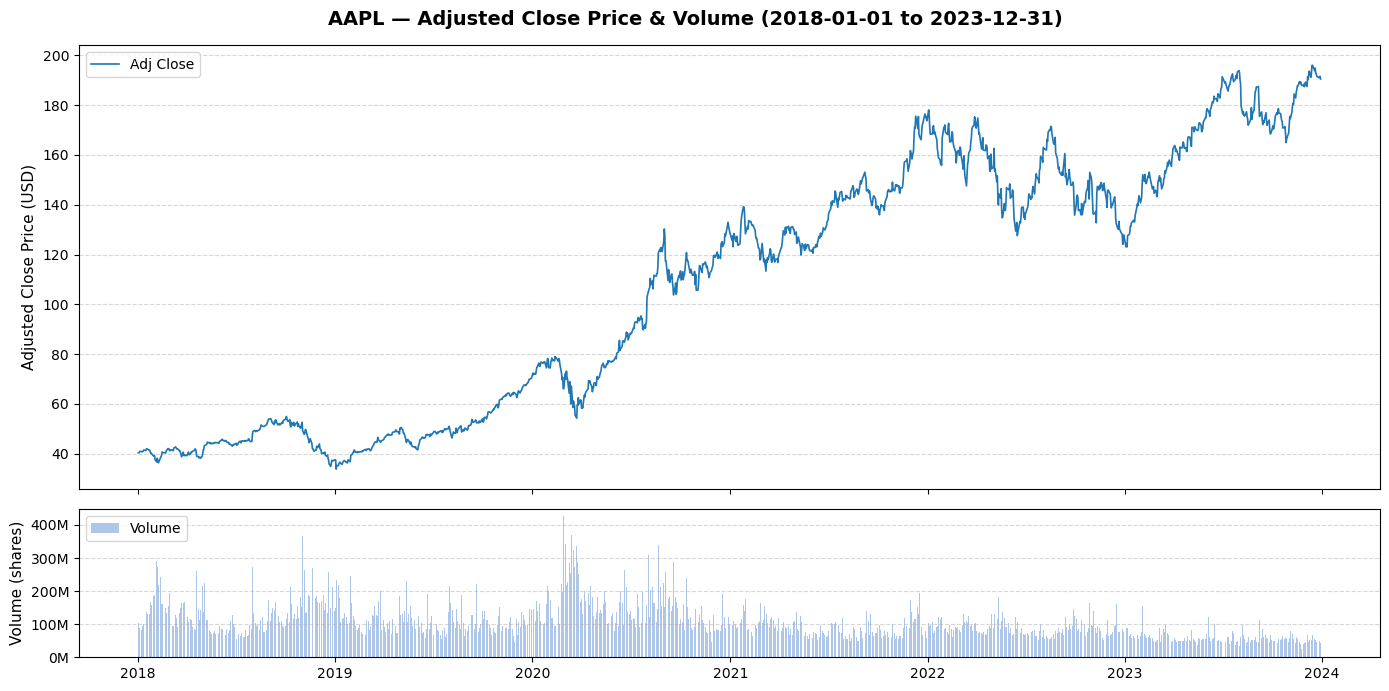

In [104]:
# APPL


def plot_price_and_volume(df: pd.DataFrame, ticker: str) -> None:
      """
      Plot Adjusted Close price and daily volume on a two-panel chart.

      Top panel    — Adjusted Close price over time
      Bottom panel — Daily trading volume as a bar chart

      Parameters
      ----------
      df : pd.DataFrame
          Cleaned, flattened DataFrame with 'Adj Close' and 'Volume' columns.
      ticker : str
          Ticker symbol used for chart title.
      """
      fig, (ax_price, ax_volume) = plt.subplots(
          nrows=2,
          ncols=1,
          figsize=(14, 7),
          sharex=True,
          gridspec_kw={"height_ratios": [3, 1]},
      )

      fig.suptitle(
          f"{ticker} — Adjusted Close Price & Volume ({START_DATE} to {END_DATE})",
          fontsize=14,
          fontweight="bold",
      )

      # Top panel: price line
      ax_price.plot(
          df.index,
          df["Adj Close"],
          color="#1f77b4",
          linewidth=1.2,
          label="Adj Close",
      )
      ax_price.set_ylabel("Adjusted Close Price (USD)", fontsize=11)
      ax_price.legend(loc="upper left", fontsize=10)
      ax_price.grid(axis="y", linestyle="--", alpha=0.5)

      # Bottom panel: volume bars
      ax_volume.bar(
          df.index,
          df["Volume"],
          color="#aec7e8",
          width=1,
          label="Volume",
      )
      ax_volume.set_ylabel("Volume (shares)", fontsize=11)
      ax_volume.yaxis.set_major_formatter(
          plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M")
      )
      ax_volume.legend(loc="upper left", fontsize=10)
      ax_volume.grid(axis="y", linestyle="--", alpha=0.5)

      ax_volume.xaxis.set_major_locator(mdates.YearLocator())
      ax_volume.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
      plt.xticks(rotation=0)

      plt.tight_layout()
      plt.show()


  # ── Run it ────────────────────────────────────────────────────────────────────
plot_price_and_volume(clean_df, TICKER)


  [INFO] Chart saved to 'section1_price_volume.png'


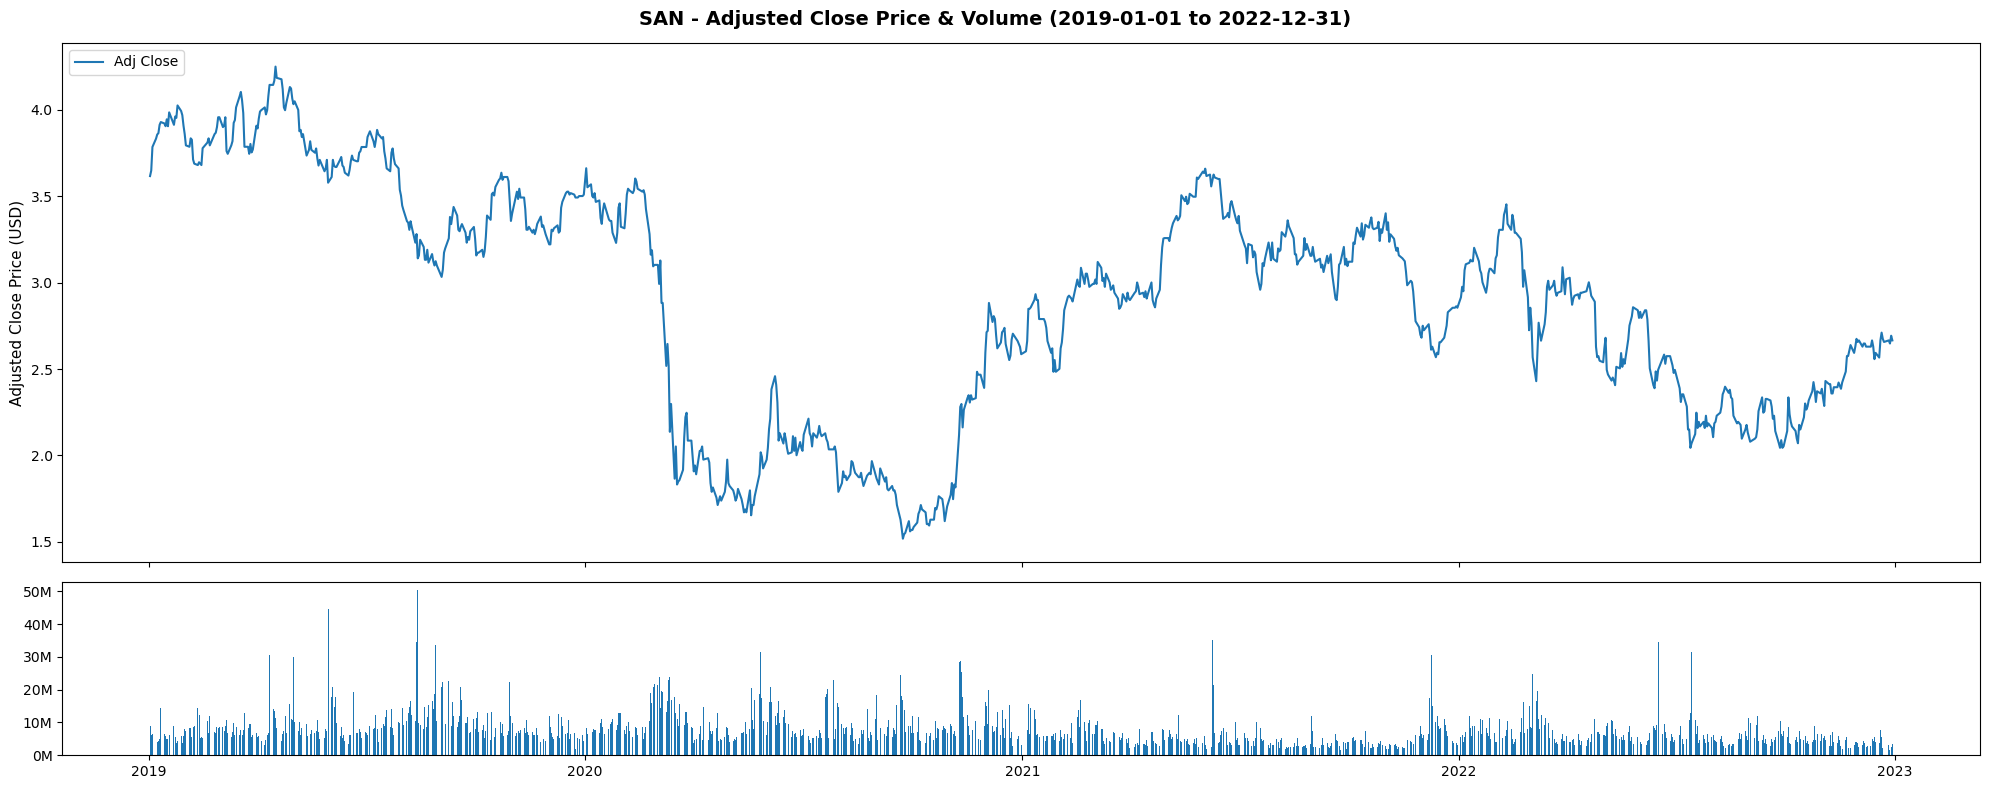

In [105]:
def plot_price_and_volume_san(df: pd.DataFrame, ticker: str) -> None:

    fig, (ax_price, ax_volume) = plt.subplots(
        nrows=2,          # tells us there will be one plot on top of the other
        ncols=1,          # tells us the plots will be stacked vertically 
        figsize=(20, 8),   # the size of the canvas
        sharex=True,      # both plots share the same x-axis 
        gridspec_kw={"height_ratios": [3, 1]},
    )  # this tells the ratio of size of each plot
    


    # Customize the title of plots 
    fig.suptitle(
        f"{ticker} - Adjusted Close Price & Volume ({START_DATE2} to {END_DATE2})",
        fontsize=14,
        fontweight="bold",
    )


    # Custimize panel on top the adjusted close price
    ax_price.plot(
        df.index,           # x-axis 
        df["Adj Close"],    # this one tells us the value in the y-axis 
        label="Adj Close",
    )

    # Customize the x and y ticks in the top panel
    ax_price.set_ylabel("Adjusted Close Price (USD)", fontsize=11)
    ax_price.legend(loc="upper left", fontsize=10)


    # Customize the panel on bot the volume
    ax_volume.bar(
        df.index,
        df["Volume"],
        label="Volume",
    )

    ax_volume.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )

    ax_volume.xaxis.set_major_locator(mdates.YearLocator())
    ax_volume.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section1_price_volume.png", dpi=150, bbox_inches="tight")
    print("\n  [INFO] Chart saved to 'section1_price_volume.png'")
    plt.show()


plot_price_and_volume_san(flattened_san, TICKER2)

    

# Section 2 - Returns & Statistics

In [106]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats  # For the normal distribution overlay on the histogram

%matplotlib inline

# ── Constants ─────────────────────────────────────────────────────────────────
# Number of trading days in a year — the universal annualisation constant
TRADING_DAYS_PER_YEAR: int = 252

In [107]:
# APPL

def compute_returns(df: pd.DataFrame) -> pd.DataFrame:
  """
  Calculate simple and log returns from the Adjusted Close price series.

  Simple return  : r_t = (P_t / P_{t-1}) - 1
  Log return     : r_t = ln(P_t / P_{t-1})

  The first row is dropped because there is no previous price to
  compute a return from — it would be NaN.

  Parameters
  ----------
  df : pd.DataFrame
      Clean DataFrame with an 'Adj Close' column.

  Returns
  -------
  pd.DataFrame
      Original DataFrame with two new columns added:
      'simple_return' and 'log_return'.
  """
  # Simple return: percentage change from the previous day
  # .pct_change() is pandas shorthand for (P_t - P_{t-1}) / P_{t-1}
  df["simple_return"] = df["Adj Close"].pct_change()

  # Log return: natural log of the price ratio
  # np.log() applies the natural logarithm element-wise across the series
  # df["Adj Close"].shift(1) shifts the entire column down by one row,
  # giving us yesterday's price aligned next to today's price
  df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))

  # Drop the first row — it has NaN returns because there is no prior price
  df = df.dropna(subset=["simple_return", "log_return"])

  print(f"[INFO] Returns computed. {len(df):,} trading days with valid returns.")
  print(f"\n  First 5 rows of return columns:")
  display(df[["Adj Close", "simple_return", "log_return"]].head())

  return df

# ── Run it ────────────────────────────────────────────────────────────────────
returns_df: pd.DataFrame = compute_returns(clean_df.copy())

[INFO] Returns computed. 1,508 trading days with valid returns.

  First 5 rows of return columns:


,Adj Close,simple_return,log_return
Date,,,
2018-01-03,40.297161,-0.000174,-0.000174
2018-01-04,40.484337,0.004645,0.004634
2018-01-05,40.945274,0.011386,0.011321
2018-01-08,40.793179,-0.003715,-0.003722
2018-01-09,40.788502,-0.000115,-0.000115


In [108]:
def compute_returns_df_san(df: pd.DataFrame) -> pd.DataFrame:

    df["simple_returns"] = df["Adj Close"].pct_change()

    df["Log_returns"] = np.log(df["Adj Close"]/df["Adj Close"].shift(1))

    df = df.dropna(subset=["simple_returns", "Log_returns"])

    print(f"[INFO] Returns computed. {len(df):,} trading days with valid returns.")
    print(f"\n  First 5 rows of return columns:")
    display(df[["Adj Close", "simple_returns" , "Log_returns"]].head())

    return df 

return_df_san: pd.DataFrame = compute_returns_df_san(flattened_san.copy())

[INFO] Returns computed. 1,007 trading days with valid returns.

  First 5 rows of return columns:


,Adj Close,simple_returns,Log_returns
Date,,,
2019-01-03,3.649187,0.008869,0.008830
2019-01-04,3.785529,0.037362,0.036681
2019-01-07,3.833651,0.012712,0.012632
2019-01-08,3.857710,0.006276,0.006256
2019-01-09,3.865731,0.002079,0.002077


In [109]:
# APPL


def compute_statistics(df: pd.DataFrame, ticker: str) -> dict:
  """
  Compute and display key return statistics, both daily and annualised.

  Statistics computed:
    - Mean simple return (daily and annual)
    - Mean log return (daily and annual)
    - Volatility — standard deviation of log returns (daily and annual)
    - Skewness of log returns
    - Kurtosis of log returns

  Parameters
  ----------
  df : pd.DataFrame
      DataFrame with 'simple_return' and 'log_return' columns.
  ticker : str
      Ticker symbol used for display labels.

  Returns
  -------
  dict
      Dictionary of all computed statistics for use in later sections.
  """
  log_ret = df["log_return"]
  simple_ret = df["simple_return"]

  # ── Daily statistics ──────────────────────────────────────────────────────
  daily_mean_log    = log_ret.mean()
  daily_mean_simple = simple_ret.mean()
  daily_vol         = log_ret.std()    # std() uses N-1 (sample std) by default
  daily_skew        = log_ret.skew()
  daily_kurt        = log_ret.kurt()   # Excess kurtosis — normal dist = 0

  # ── Annualised statistics ─────────────────────────────────────────────────
  # Mean scales linearly: multiply by 252
  # Volatility scales by square root: multiply by √252
  annual_mean_log    = daily_mean_log  * TRADING_DAYS_PER_YEAR
  annual_mean_simple = daily_mean_simple * TRADING_DAYS_PER_YEAR
  annual_vol         = daily_vol       * np.sqrt(TRADING_DAYS_PER_YEAR)

  # ── Print report ──────────────────────────────────────────────────────────
  print("=" * 60)
  print(f"  RETURN STATISTICS — {ticker}")
  print("=" * 60)

  print(f"\n  {'Metric':<35} {'Daily':>10} {'Annual':>10}")
  print(f"  {'-'*55}")
  print(f"  {'Mean Log Return':<35} {daily_mean_log:>10.4%} {annual_mean_log:>10.4%}")      
  print(f"  {'Mean Simple Return':<35} {daily_mean_simple:>10.4%} {annual_mean_simple:>10.4%}")
  print(f"  {'Volatility (Log Returns)':<35} {daily_vol:>10.4%} {annual_vol:>10.4%}")       
  print(f"\n  {'Skewness':<35} {daily_skew:>10.4f}")
  print(f"  {'Excess Kurtosis':<35} {daily_kurt:>10.4f}")

  print(f"\n  Notes:")
  print(f"  - Skewness < 0 means the distribution has a longer left tail")
  print(f"    (more frequent small gains, rarer but larger losses)")
  print(f"  - Excess kurtosis > 0 means fatter tails than a normal distribution")
  print(f"    (extreme moves happen more often than standard models assume)")

  # Return all stats as a dictionary so future sections can use them
  return {
      "daily_mean_log"    : daily_mean_log,
      "daily_mean_simple" : daily_mean_simple,
      "daily_vol"         : daily_vol,
      "annual_mean_log"   : annual_mean_log,
      "annual_mean_simple": annual_mean_simple,
      "annual_vol"        : annual_vol,
      "skewness"          : daily_skew,
      "excess_kurtosis"   : daily_kurt,
  }

# ── Run it ────────────────────────────────────────────────────────────────────
stats_dict: dict = compute_statistics(returns_df, TICKER)

  RETURN STATISTICS — AAPL

  Metric                                   Daily     Annual
  -------------------------------------------------------
  Mean Log Return                        0.1030%   25.9597%
  Mean Simple Return                     0.1230%   30.9906%
  Volatility (Log Returns)               1.9965%   31.6939%

  Skewness                               -0.2447
  Excess Kurtosis                         5.0799

  Notes:
  - Skewness < 0 means the distribution has a longer left tail
    (more frequent small gains, rarer but larger losses)
  - Excess kurtosis > 0 means fatter tails than a normal distribution
    (extreme moves happen more often than standard models assume)


In [110]:
def comput_statistics_san(df: pd.DataFrame, ticker: str) 

SyntaxError: expected ':' (1280696024.py, line 1)

In [ ]:
def plot_return_distribution(df: pd.DataFrame, ticker: str) -> None:        
  """
  Plot the distribution of daily log returns as a histogram,
  overlaid with a fitted normal distribution curve for comparison.        

  This reveals whether returns are symmetric, skewed, or fat-tailed —     
  properties that matter for every downstream model and risk calculation. 

  Parameters
  ----------
  df : pd.DataFrame
      DataFrame with a 'log_return' column.
  ticker : str
      Ticker symbol used for chart title.
  """
  log_ret = df["log_return"].dropna()

  # Fit a normal distribution to the return data
  # stats.norm.fit() returns the mean (mu) and std (sigma) of the best-fit normal
  mu, sigma = stats.norm.fit(log_ret)

  fig, ax = plt.subplots(figsize=(12, 6))

  # ── Histogram of actual returns───────────────────────────────────────────
  # density=True normalises the histogram so the y-axis shows
  # probability density instead of raw counts — required to overlay       
  # the normal distribution curve on the same scale
  ax.hist(
      log_ret,
      bins=100,           # 100 bins gives good resolution for 1,500 days  of data
      density=True,
      color="#1f77b4",
      alpha=0.6,          # Slight transparency so the curve shows through
      label="Actual returns",
      edgecolor="white",
      linewidth=0.3,
  )

  # ── Normal distribution overlay───────────────────────────────────────────
  # Generate 1,000 evenly spaced x values across the return range
  x = np.linspace(log_ret.min(), log_ret.max(), 1000)

  # stats.norm.pdf() computes the probability density function of the     
  # normal distribution at each x value using our fitted mu and sigma     
  ax.plot(
      x,
      stats.norm.pdf(x, mu, sigma),
      color="#d62728",    # Red — visually distinct from the blue histogram
      linewidth=2,
      label=f"Normal fit  (μ={mu:.4f}, σ={sigma:.4f})",
  )

  # ── Vertical line at zero─────────────────────────────────────────────────
  # Shows visually whether the distribution is centred above or below zero
  ax.axvline(
      x=0,
      color="black",
      linestyle="--",
      linewidth=1,
      alpha=0.7,
      label="Zero return",
  )

  # ── Labels and formatting─────────────────────────────────────────────────
  ax.set_title(
      f"{ticker} — Daily Log Return Distribution ({len(log_ret):,}        observations)",
      fontsize=14,
      fontweight="bold",
  )
  ax.set_xlabel("Daily Log Return", fontsize=12)
  ax.set_ylabel("Probability Density", fontsize=12)
  ax.legend(fontsize=11)
  ax.grid(axis="y", linestyle="--", alpha=0.4)

  # Format x-axis as percentages
  ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1,decimals=1))

  plt.tight_layout()
  plt.savefig("section2_return_distribution.png", dpi=150,bbox_inches="tight")
  print("[INFO] Chart saved to 'section2_return_distribution.png'")       
  plt.show()

# ── Run it────────────────────────────────────────────────────────────────────        
plot_return_distribution(returns_df, TICKER)

In [ ]:
def plot_cumulative_returns(df: pd.DataFrame, ticker: str) -> None:
  """
  Plot the cumulative log return over time — showing how $1 invested
  at the start grows (or shrinks) through the entire period.

  Cumulative log return is computed by summing daily log returns.
  This works because log returns are additive across time.

  Parameters
  ----------
  df : pd.DataFrame
      DataFrame with a 'log_return' column.
  ticker : str
      Ticker symbol used for chart title.
  """
  # .cumsum() computes the running total — each row is the sum of
  # all log returns from the first day up to and including that day
  cumulative_log_return = df["log_return"].cumsum()

  # Convert cumulative log return back to a price index starting at 1.0
  # np.exp() is the inverse of np.log() — it reverses the logarithm
  # So if cumulative log return = 0.5, then np.exp(0.5) ≈ 1.65
  # meaning $1 grew to $1.65
  growth_of_one_dollar = np.exp(cumulative_log_return)

  fig, ax = plt.subplots(figsize=(14, 6))

  ax.plot(
      df.index,
      growth_of_one_dollar,
      color="#1f77b4",
      linewidth=1.5,
      label=f"{ticker} — Growth of $1",
  )

  # Horizontal reference line at $1 — the starting value
  ax.axhline(
      y=1.0,
      color="black",
      linestyle="--",
      linewidth=1,
      alpha=0.6,
      label="Starting value ($1)",
  )

  ax.set_title(
      f"{ticker} — Cumulative Return (Growth of $1 Invested)",
      fontsize=14,
      fontweight="bold",
  )
  ax.set_xlabel("Date", fontsize=12)
  ax.set_ylabel("Portfolio Value ($)", fontsize=12)
  ax.legend(fontsize=11)
  ax.grid(axis="y", linestyle="--", alpha=0.4)

  plt.tight_layout()
  plt.savefig("section2_cumulative_return.png", dpi=150, bbox_inches="tight")
  print("[INFO] Chart saved to 'section2_cumulative_return.png'")
  plt.show()

# ── Run it ────────────────────────────────────────────────────────────────────
plot_cumulative_returns(returns_df, TICKER)

# Section 3 - Technical indicators

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────   

import numpy as np                                                                               
import pandas as pd                                                                            
import matplotlib.pyplot as plt                                                                
import matplotlib.dates as mdates                                                                 
%matplotlib inline                                                                                
# ── Constants ─────────────────────────────────────────────────────────────────               
SMA_SHORT:  int = 50    # Short-term moving average window (days)
SMA_LONG:   int = 200   # Long-term moving average window (days)                               
RSI_PERIOD: int = 14    # Standard RSI lookback period (days)  

In [ ]:
def compute_sma(df: pd.DataFrame) -> pd.DataFrame:                                                                                         
    df[f"SMA_{SMA_SHORT}"] = df["Adj Close"].rolling(window=SMA_SHORT).mean()
    df[f"SMA_{SMA_LONG}"]  = df["Adj Close"].rolling(window=SMA_LONG).mean()                   
    print(f"[INFO] SMA_{SMA_SHORT} and SMA_{SMA_LONG} computed.")                                    
    print(f"       First valid SMA_{SMA_SHORT} date : {df[f'SMA_{SMA_SHORT}'].first_valid_index().date()}")                                                
    print(f"       First valid SMA_{SMA_LONG} date  : {df[f'SMA_{SMA_LONG}'].first_valid_index().date()}")                                              
    return df                                                                                  

# ── Run it ────────────────────────────────────────────────────────────────────               
indicators_df: pd.DataFrame = compute_sma(returns_df.copy())                                   
                                                                

In [ ]:
def compute_rsi(df: pd.DataFrame, period: int = RSI_PERIOD) -> pd.DataFrame:
    """
    Compute the Relative Strength Index (RSI) using a simple rolling mean.

    Steps:
        1. Compute daily price changes
        2. Separate into gains (positive changes) and losses (negative changes)
        3. Compute rolling average gain and average loss over the window
        4. RS  = Avg Gain / Avg Loss
        5. RSI = 100 - (100 / (1 + RS))

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with an 'Adj Close' column.
    period : int
        RSI lookback window. Default is 14 days (industry standard).

    Returns
    -------
    pd.DataFrame
        Original DataFrame with 'RSI' column added.
    """
    # Step 1: Daily price change
    delta: pd.Series = df["Adj Close"].diff()

    # Step 2: Separate gains and losses
    # .clip(lower=0) zeroes out all negative values — keeps only gains
    # (-delta).clip(lower=0) flips the sign then zeroes negatives — keeps only losses
    gain: pd.Series = delta.clip(lower=0)
    loss: pd.Series = (-delta).clip(lower=0)

    # Step 3: Rolling average gain and loss
    avg_gain: pd.Series = gain.rolling(window=period).mean()
    avg_loss: pd.Series = loss.rolling(window=period).mean()

    # Step 4: Relative Strength
    rs: pd.Series = avg_gain / avg_loss

    # Step 5: RSI formula — maps RS onto 0–100 scale
    df["RSI"] = 100 - (100 / (1 + rs))

    print(f"[INFO] RSI({period}) computed.")
    print(f"       First valid RSI date: {df['RSI'].first_valid_index().date()}")

    return df
indicators_df = compute_rsi(indicators_df) 

In [ ]:
def plot_indicators(df: pd.DataFrame, ticker: str) -> None:
    """
    Three-panel chart: price with SMA overlays, RSI, and volume.
    """
    fig, (ax_price, ax_rsi, ax_vol) = plt.subplots(
        nrows=3, ncols=1, figsize=(16, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1.5, 1]},
    )

    fig.suptitle(
        f"{ticker} — Price, SMA, RSI & Volume ({START_DATE} to {END_DATE})",
        fontsize=14, fontweight="bold",
    )

    # Price + SMA
    ax_price.plot(df.index, df["Adj Close"], color="#1f77b4", linewidth=1.0,
                  label="Adj Close", alpha=0.9)
    ax_price.plot(df.index, df[f"SMA_{SMA_SHORT}"], color="#ff7f0e", linewidth=1.5,
                  label=f"SMA {SMA_SHORT}")
    ax_price.plot(df.index, df[f"SMA_{SMA_LONG}"],  color="#2ca02c", linewidth=1.5,
                  label=f"SMA {SMA_LONG}")
    ax_price.set_ylabel("Adjusted Close Price (USD)", fontsize=11)
    ax_price.legend(loc="upper left", fontsize=10)
    ax_price.grid(axis="y", linestyle="--", alpha=0.4)

    # RSI
    ax_rsi.plot(df.index, df["RSI"], color="#9467bd", linewidth=1.2,
                label=f"RSI({RSI_PERIOD})")
    ax_rsi.axhline(y=70, color="red",   linestyle="--", linewidth=1, alpha=0.7,
                   label="Overbought (70)")
    ax_rsi.axhline(y=30, color="green", linestyle="--", linewidth=1, alpha=0.7,
                   label="Oversold (30)")
    ax_rsi.axhline(y=50, color="gray",  linestyle=":",  linewidth=0.8, alpha=0.5)
    ax_rsi.fill_between(df.index, 70, df["RSI"], where=(df["RSI"] >= 70),
                        alpha=0.2, color="red")
    ax_rsi.fill_between(df.index, 30, df["RSI"], where=(df["RSI"] <= 30),
                        alpha=0.2, color="green")
    ax_rsi.set_ylabel(f"RSI ({RSI_PERIOD})", fontsize=11)
    ax_rsi.set_ylim(0, 100)
    ax_rsi.legend(loc="upper left", fontsize=9)
    ax_rsi.grid(axis="y", linestyle="--", alpha=0.4)

    # Volume
    ax_vol.bar(df.index, df["Volume"], color="#aec7e8", width=1, label="Volume")
    ax_vol.set_ylabel("Volume", fontsize=11)
    ax_vol.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))
    ax_vol.legend(loc="upper left", fontsize=9)
    ax_vol.grid(axis="y", linestyle="--", alpha=0.4)

    ax_vol.xaxis.set_major_locator(mdates.YearLocator())
    ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section3_indicators.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_indicators(indicators_df, TICKER)

# Section 4 - Creating indicators

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline

# ── Strategy parameters ───────────────────────────────────────────────────────
SMA_SHORT: int = 50
SMA_LONG:  int = 200

In [ ]:
def generate_signals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a Moving Average Crossover signal vector.

    Rule:
        - SMA_50 > SMA_200  →  position = 1  (hold long)
        - SMA_50 < SMA_200  →  position = 0  (stay flat)

    A trade entry occurs when position changes from 0 → 1 (buy).
    A trade exit  occurs when position changes from 1 → 0 (sell).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'SMA_50' and 'SMA_200' columns.

    Returns
    -------
    pd.DataFrame
        Original DataFrame with 'signal' and 'position' columns added.
    """
    # Raw signal: 1 when SMA_50 is above SMA_200, 0 otherwise
    df["signal"] = np.where(
        df[f"SMA_{SMA_SHORT}"] > df[f"SMA_{SMA_LONG}"], 1, 0
    )

    # Position: shift by 1 bar — act on tomorrow's open, not today's close.
    # This prevents lookahead bias.
    df["position"] = df["signal"].shift(1)

    # Drop the first row where position is NaN (no prior signal exists)
    df = df.dropna(subset=["position"])
    print(df)
    return df

signals_df = generate_signals(indicators_df.copy())

In [ ]:
def summarise_trades(df: pd.DataFrame, ticker: str) -> None:
    """
    Print a summary of all trades generated by the signal.

    A new trade is identified every time the position changes:
        0 → 1  =  buy  (entry)
        1 → 0  =  sell (exit)

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a 'position' column.
    ticker : str
        Ticker symbol used for display labels.
    """
    position_change = df["position"].diff()

    entries = df.index[position_change ==  1]   # 0 → 1  (buy)
    exits   = df.index[position_change == -1]   # 1 → 0  (sell)

    print("=" * 60)
    print(f"  TRADE SUMMARY — {ticker}")
    print("=" * 60)
    print(f"\n  Total buy  signals : {len(entries)}")
    print(f"  Total sell signals : {len(exits)}")
    print(f"\n  {'#':<5} {'Entry Date':<15} {'Exit Date':<15}")
    print(f"  {'-' * 35}")

    for i, (entry, exit_) in enumerate(zip(entries, exits), start=1):
        print(f"  {i:<5} {str(entry.date()):<15} {str(exit_.date()):<15}")

summarise_trades(signals_df, TICKER)

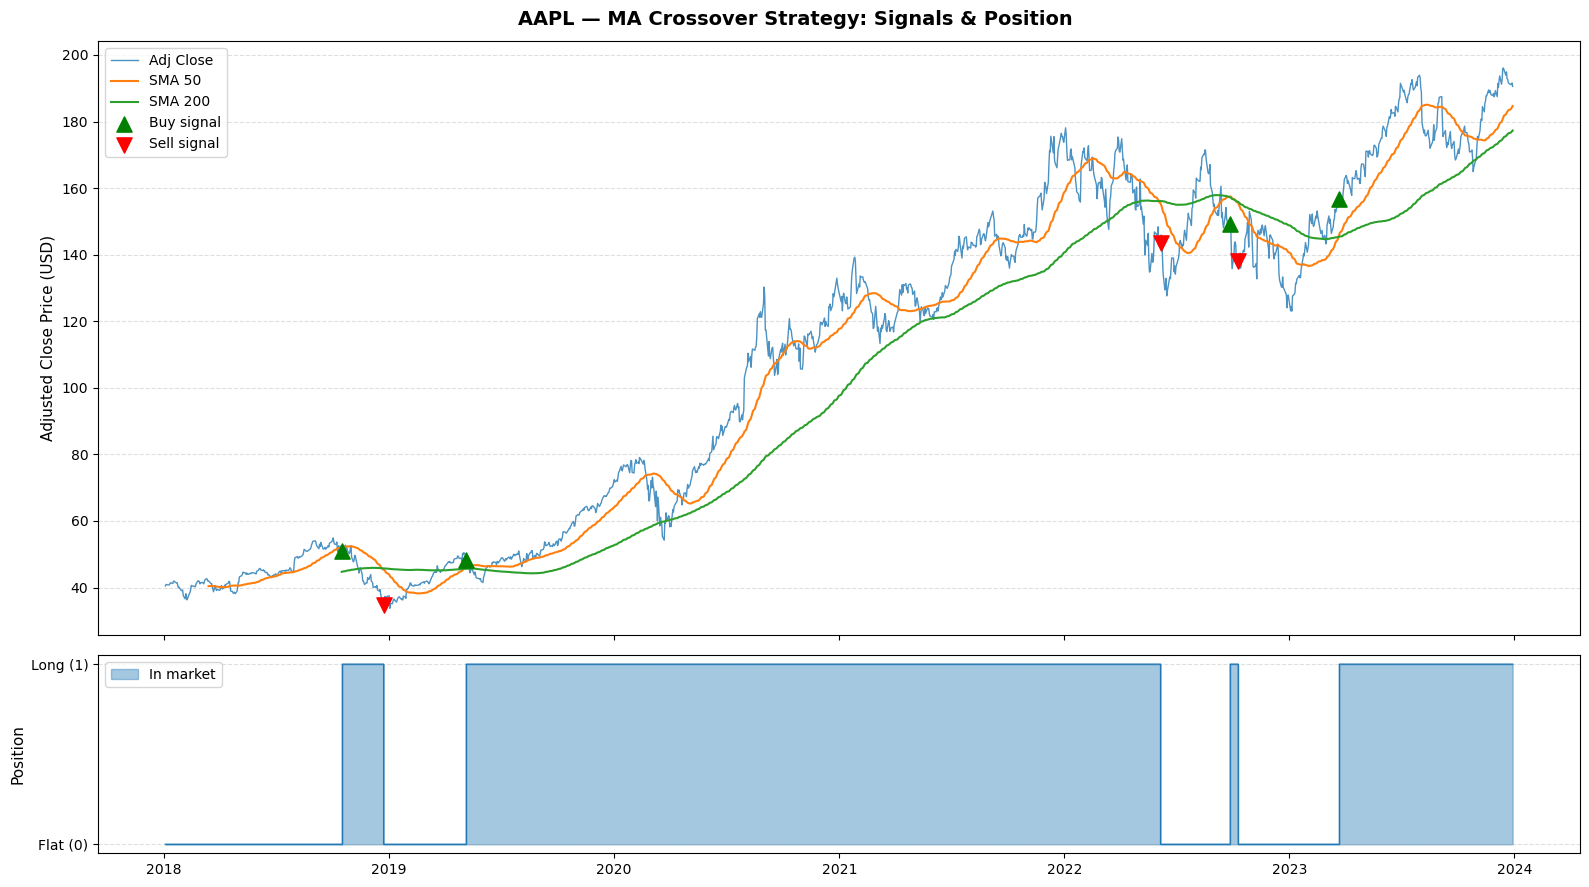

In [111]:
def plot_signals(df: pd.DataFrame, ticker: str) -> None:
    """
    Plot price with SMA overlays and buy/sell signal markers.

    Top panel    — Adjusted Close with SMA_50, SMA_200, and trade markers.
    Bottom panel — Position (1 = in market, 0 = out of market).

    Buy markers  — green triangles pointing up   (entry points)
    Sell markers — red   triangles pointing down (exit  points)

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'Adj Close', 'SMA_50', 'SMA_200', 'position' columns.
    ticker : str
        Ticker symbol used for chart title.
    """
    position_change = df["position"].diff()
    entries = df[position_change ==  1]
    exits   = df[position_change == -1]

    fig, (ax_price, ax_pos) = plt.subplots(
        nrows=2, ncols=1,
        figsize=(16, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    fig.suptitle(
        f"{ticker} — MA Crossover Strategy: Signals & Position",
        fontsize=14, fontweight="bold",
    )

    # ── Top panel: Price + SMAs ───────────────────────────────────────────────
    ax_price.plot(df.index, df["Adj Close"],
                  color="#1f77b4", linewidth=1.0, label="Adj Close", alpha=0.8)
    ax_price.plot(df.index, df[f"SMA_{SMA_SHORT}"],
                  color="#ff7f0e", linewidth=1.5, label=f"SMA {SMA_SHORT}")
    ax_price.plot(df.index, df[f"SMA_{SMA_LONG}"],
                  color="#2ca02c", linewidth=1.5, label=f"SMA {SMA_LONG}")

    ax_price.scatter(entries.index, entries["Adj Close"],
                     marker="^", color="green", s=120, zorder=5, label="Buy signal")
    ax_price.scatter(exits.index, exits["Adj Close"],
                     marker="v", color="red",   s=120, zorder=5, label="Sell signal")

    ax_price.set_ylabel("Adjusted Close Price (USD)", fontsize=11)
    ax_price.legend(loc="upper left", fontsize=10)
    ax_price.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Bottom panel: Position ────────────────────────────────────────────────
    ax_pos.fill_between(df.index, df["position"],
                        step="post", alpha=0.4, color="#1f77b4", label="In market")
    ax_pos.plot(df.index, df["position"],
                drawstyle="steps-post", color="#1f77b4", linewidth=1.0)

    ax_pos.set_ylabel("Position", fontsize=11)
    ax_pos.set_yticks([0, 1])
    ax_pos.set_yticklabels(["Flat (0)", "Long (1)"])
    ax_pos.legend(loc="upper left", fontsize=10)
    ax_pos.grid(axis="y", linestyle="--", alpha=0.4)

    ax_pos.xaxis.set_major_locator(mdates.YearLocator())
    ax_pos.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section4_signals.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_signals(signals_df, TICKER)


# Section 5 - Backtesting


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline

# ── Strategy parameters ───────────────────────────────────────────────────────
TRANSACTION_COST: float = 0.001  # 0.1% per trade — realistic retail commission

In [118]:
def run_backtest(df: pd.DataFrame) -> pd.DataFrame:
    """
    Simulate the MA crossover strategy on historical data.

    For each day:
        - Strategy return  = position(t-1) × log_return(t)
        - Transaction cost is deducted on days where position changes

    Buy-and-hold benchmark simply holds the asset every day:
        - Benchmark return = log_return(t) for all days

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'log_return' and 'position' columns.

    Returns
    -------
    pd.DataFrame
        Original DataFrame with strategy and benchmark return columns added.
    """
    # Daily strategy return — position from prior day applied to today's return
    df["strategy_return"] = df["position"] * df["log_return"]

    # Identify days where the position changed — these incur transaction costs
    position_change = df["position"].diff().abs()
    df["strategy_return"] -= position_change * TRANSACTION_COST

    # Buy-and-hold benchmark — fully invested every single day
    df["benchmark_return"] = df["log_return"]

    # Cumulative returns — running sum of log returns converted to dollar growth
    df["strategy_equity"]  = np.exp(df["strategy_return"].cumsum())
    df["benchmark_equity"] = np.exp(df["benchmark_return"].cumsum())

    print(f"[INFO] Backtest complete.")
    print(f"  Transaction cost applied : {TRANSACTION_COST:.1%} per trade")
    print(f"  Strategy final value     : ${df['strategy_equity'].iloc[-1]:.2f}")
    print(f"  Benchmark final value    : ${df['benchmark_equity'].iloc[-1]:.2f}")

    return df

In [115]:
def plot_equity_curves(df: pd.DataFrame, ticker: str) -> None:
    """
    Plot strategy equity curve vs buy-and-hold benchmark.

    Both curves start at $1 on the first day and show the compounded
    growth of capital through the full backtest period.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'strategy_equity' and 'benchmark_equity' columns.
    ticker : str
        Ticker symbol used for chart title.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(df.index, df["strategy_equity"],
            color="#ff7f0e", linewidth=1.5, label="MA Crossover Strategy")
    ax.plot(df.index, df["benchmark_equity"],
            color="#1f77b4", linewidth=1.5, label="Buy & Hold Benchmark", alpha=0.8)

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

    ax.set_title(
        f"{ticker} — Strategy vs Buy & Hold (Growth of $1)",
        fontsize=14, fontweight="bold",
    )
    ax.set_ylabel("Portfolio Value ($)", fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section5_equity_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

In [116]:
def plot_drawdowns(df: pd.DataFrame, ticker: str) -> None:
    """
    Plot the drawdown over time for both strategy and benchmark.

    Drawdown at each point = (current value - peak value so far) / peak value
    This shows how far below the all-time high the portfolio sits at each day.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'strategy_equity' and 'benchmark_equity' columns.
    ticker : str
        Ticker symbol used for chart title.
    """
    strategy_peak  = df["strategy_equity"].cummax()
    benchmark_peak = df["benchmark_equity"].cummax()

    strategy_dd  = (df["strategy_equity"]  - strategy_peak)  / strategy_peak
    benchmark_dd = (df["benchmark_equity"] - benchmark_peak) / benchmark_peak

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.fill_between(df.index, strategy_dd,
                    alpha=0.4, color="#ff7f0e", label="Strategy Drawdown")
    ax.fill_between(df.index, benchmark_dd,
                    alpha=0.3, color="#1f77b4", label="Benchmark Drawdown")

    ax.set_title(
        f"{ticker} — Drawdown Over Time",
        fontsize=14, fontweight="bold",
    )
    ax.set_ylabel("Drawdown (%)", fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.legend(fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section5_drawdowns.png", dpi=150, bbox_inches="tight")
    plt.show()

Date
2018-01-04         NaN
2018-01-05    1.000000
2018-01-08    1.000000
2018-01-09    1.000000
2018-01-10    1.000000
                ...   
2023-12-22    2.229387
2023-12-26    2.223054
2023-12-27    2.224205
2023-12-28    2.229157
2023-12-29    2.217066
Name: strategy_equity, Length: 1507, dtype: float64
[INFO] Backtest complete.
  Transaction cost applied : 0.1% per trade
  Strategy final value     : $2.22
  Benchmark final value    : $4.73


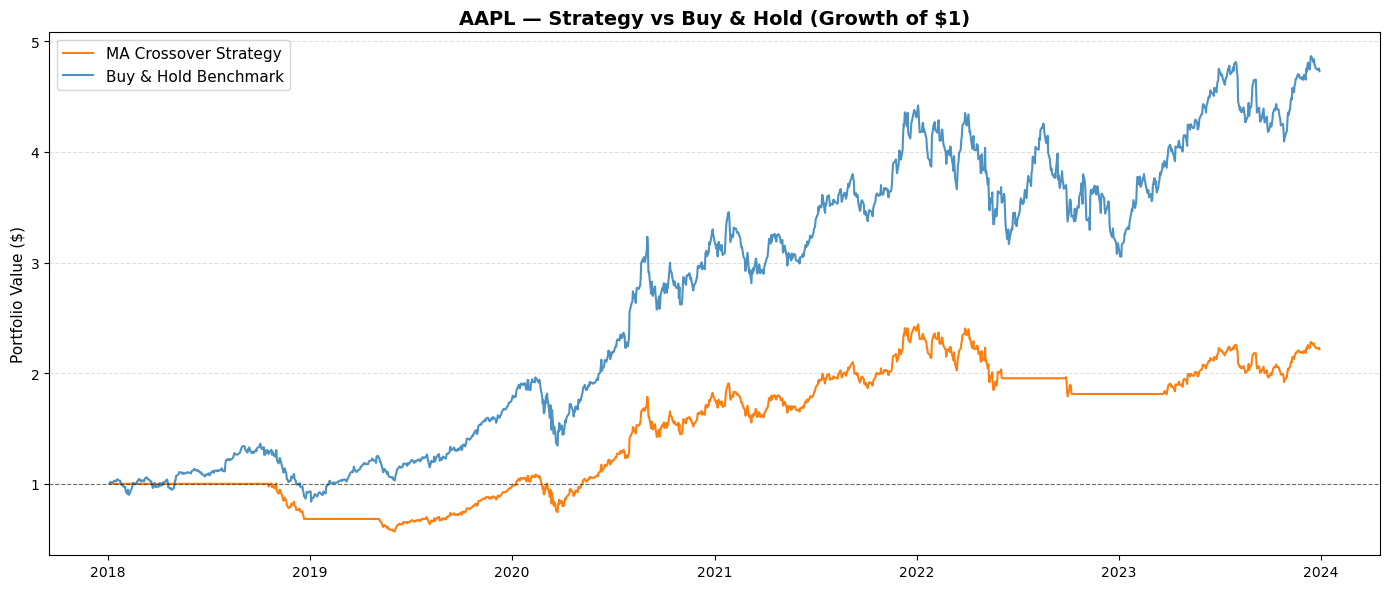

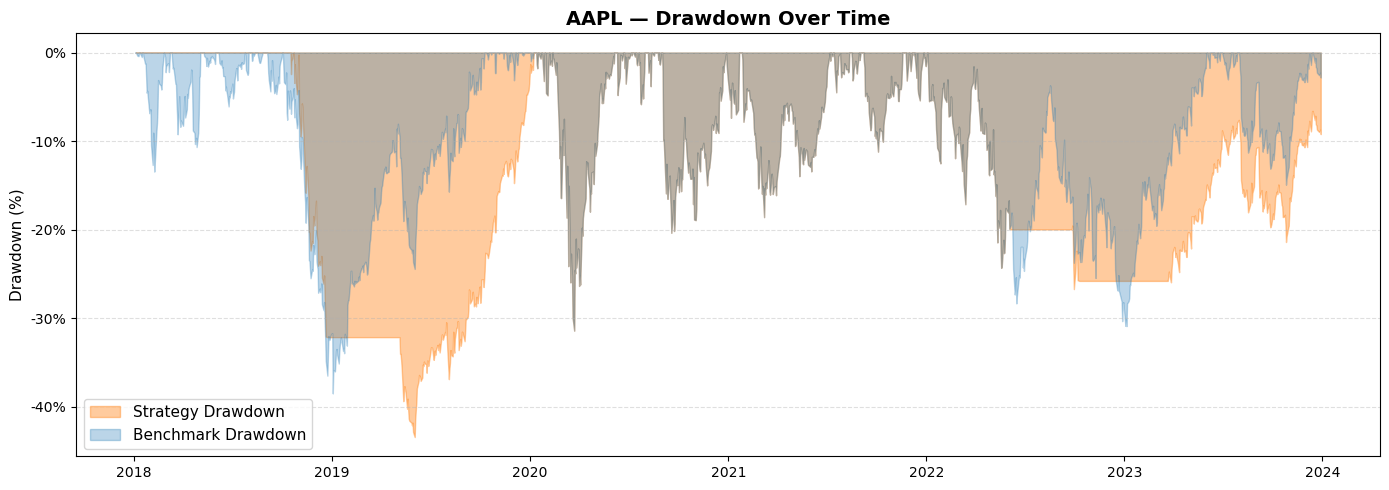

In [119]:
# ── Run ───────────────────────────────────────────────────────────────────────
backtest_df = run_backtest(signals_df.copy())
plot_equity_curves(backtest_df, TICKER)
plot_drawdowns(backtest_df, TICKER)

# Section 6 - Performace metrics

In [126]:
import numpy as np
import pandas as pd

# ── Constants ─────────────────────────────────────────────────────────────────
TRADING_DAYS_PER_YEAR: int   = 252
RISK_FREE_RATE:        float = 0.05  # 5% annual — approximate US T-bill rate

In [127]:
def compute_sharpe_ratio(returns: pd.Series, risk_free_rate: float = RISK_FREE_RATE) -> float:
    """
    Compute the annualised Sharpe Ratio.

    Sharpe = (Annual Mean Return - Risk Free Rate) / Annual Volatility

    Measures return earned per unit of risk taken.
    A Sharpe above 1.0 is considered acceptable.
    Above 2.0 is considered strong. Above 3.0 is exceptional.

    Parameters
    ----------
    returns : pd.Series
        Daily log return series.
    risk_free_rate : float
        Annual risk-free rate as a decimal (e.g. 0.05 for 5%).

    Returns
    -------
    float
        Annualised Sharpe Ratio.
    """
    daily_rf      = risk_free_rate / TRADING_DAYS_PER_YEAR
    excess_return = returns - daily_rf
    mean          = excess_return.mean() * TRADING_DAYS_PER_YEAR
    vol           = excess_return.std()  * np.sqrt(TRADING_DAYS_PER_YEAR)
    return mean / vol

In [128]:
def compute_max_drawdown(equity_curve: pd.Series) -> float:
    """
    Compute Maximum Drawdown — the largest peak-to-trough decline.

    Max Drawdown = min((V_t - Peak_t) / Peak_t) over all t

    Measures the worst loss an investor would have experienced
    if they bought at the peak and held to the worst subsequent trough.

    Parameters
    ----------
    equity_curve : pd.Series
        Cumulative portfolio value series starting at 1.0.

    Returns
    -------
    float
        Maximum drawdown as a negative decimal (e.g. -0.35 = -35%).
    """
    peak     = equity_curve.cummax()
    drawdown = (equity_curve - peak) / peak
    return drawdown.min()

In [129]:
def compute_win_rate(strategy_returns: pd.Series, position: pd.Series) -> float:
    """
    Compute Win Rate — fraction of active trading days with positive returns.

    Only counts days when we were actually in the market (position = 1).
    Days when position = 0 are excluded — no trade means no win or loss.

    Parameters
    ----------
    strategy_returns : pd.Series
        Daily strategy log returns.
    position : pd.Series
        Daily position (1 = long, 0 = flat).

    Returns
    -------
    float
        Win rate as a decimal between 0 and 1.
    """
    active_returns = strategy_returns[position == 1]
    return (active_returns > 0).sum() / len(active_returns)

In [130]:
def compute_calmar_ratio(equity_curve: pd.Series) -> float:
    """
    Compute the Calmar Ratio — annual return divided by max drawdown.

    Calmar = Annualised Return / |Max Drawdown|

    A higher Calmar means the strategy generates more return per unit
    of drawdown risk. Preferred by institutional investors over Sharpe
    because it focuses on tail risk, not average volatility.

    Parameters
    ----------
    equity_curve : pd.Series
        Cumulative portfolio value series.

    Returns
    -------
    float
        Calmar Ratio (positive number).
    """
    total_return   = np.log(equity_curve.iloc[-1] / equity_curve.iloc[0])
    n_years        = len(equity_curve) / TRADING_DAYS_PER_YEAR
    annualised_ret = total_return / n_years
    max_dd         = abs(compute_max_drawdown(equity_curve))
    return annualised_ret / max_dd if max_dd != 0 else np.nan

In [131]:
def print_performance_report(df: pd.DataFrame, ticker: str) -> None:
    """
    Print a full performance report comparing strategy vs benchmark.

    Metrics computed for both:
        - Annualised Return
        - Annualised Volatility
        - Sharpe Ratio
        - Maximum Drawdown
        - Calmar Ratio
        - Win Rate       (strategy only)
        - Time in Market (strategy only)

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'strategy_return', 'benchmark_return',
        'strategy_equity', 'benchmark_equity', 'position' columns.
    ticker : str
        Ticker symbol used for display labels.
    """
    # ── Strategy metrics ──────────────────────────────────────────────────────
    strat_sharpe  = compute_sharpe_ratio(df["strategy_return"])
    strat_mdd     = compute_max_drawdown(df["strategy_equity"])
    strat_calmar  = compute_calmar_ratio(df["strategy_equity"])
    strat_winrate = compute_win_rate(df["strategy_return"], df["position"])
    strat_ann_ret = df["strategy_return"].mean() * TRADING_DAYS_PER_YEAR
    strat_ann_vol = df["strategy_return"].std()  * np.sqrt(TRADING_DAYS_PER_YEAR)
    time_in_mkt   = df["position"].mean()

    # ── Benchmark metrics ─────────────────────────────────────────────────────
    bench_sharpe  = compute_sharpe_ratio(df["benchmark_return"])
    bench_mdd     = compute_max_drawdown(df["benchmark_equity"])
    bench_calmar  = compute_calmar_ratio(df["benchmark_equity"])
    bench_ann_ret = df["benchmark_return"].mean() * TRADING_DAYS_PER_YEAR
    bench_ann_vol = df["benchmark_return"].std()  * np.sqrt(TRADING_DAYS_PER_YEAR)

    # ── Print report ──────────────────────────────────────────────────────────
    print("=" * 65)
    print(f"  PERFORMANCE REPORT — {ticker}")
    print("=" * 65)
    print(f"\n  {'Metric':<30} {'Strategy':>15} {'Benchmark':>15}")
    print(f"  {'-' * 60}")
    print(f"  {'Annualised Return':<30} {strat_ann_ret:>15.2%} {bench_ann_ret:>15.2%}")
    print(f"  {'Annualised Volatility':<30} {strat_ann_vol:>15.2%} {bench_ann_vol:>15.2%}")
    print(f"  {'Sharpe Ratio':<30} {strat_sharpe:>15.2f} {bench_sharpe:>15.2f}")
    print(f"  {'Maximum Drawdown':<30} {strat_mdd:>15.2%} {bench_mdd:>15.2%}")
    print(f"  {'Calmar Ratio':<30} {strat_calmar:>15.2f} {bench_calmar:>15.2f}")
    print(f"  {'Win Rate (active days)':<30} {strat_winrate:>15.2%} {'N/A':>15}")
    print(f"  {'Time in Market':<30} {time_in_mkt:>15.2%} {'100.00%':>15}")

    print(f"\n  INTERPRETATION")
    print(f"  {'-' * 60}")

    if strat_sharpe > bench_sharpe:
        print(f"  [+] Strategy has a higher Sharpe — better risk-adjusted return")
    else:
        print(f"  [-] Strategy has a lower Sharpe — worse risk-adjusted return than buy & hold")

    if abs(strat_mdd) < abs(bench_mdd):
        print(f"  [+] Strategy has a smaller max drawdown — less downside pain")
    else:
        print(f"  [-] Strategy has a larger max drawdown — more downside pain")

    if strat_ann_ret > bench_ann_ret:
        print(f"  [+] Strategy outperformed buy & hold in raw annual return")
    else:
        print(f"  [-] Strategy underperformed buy & hold in raw annual return")

    print(f"\n  HONEST LIMITATIONS")
    print(f"  {'-' * 60}")
    print(f"  - Results are in-sample: strategy was built on the same data it was tested on")
    print(f"  - No walk-forward or out-of-sample validation was performed")
    print(f"  - SMA windows (50/200) were chosen by convention, not optimised statistically")
    print(f"  - A single 6-year period may not represent all market regimes")

In [132]:
# ── Run ───────────────────────────────────────────────────────────────────────
print_performance_report(backtest_df, TICKER)

  PERFORMANCE REPORT — AAPL

  Metric                                Strategy       Benchmark
  ------------------------------------------------------------
  Annualised Return                       13.32%          25.98%
  Annualised Volatility                   27.11%          31.70%
  Sharpe Ratio                              0.31            0.66
  Maximum Drawdown                       -43.45%         -38.52%
  Calmar Ratio                               nan            0.67
  Win Rate (active days)                  52.53%             N/A
  Time in Market                          68.08%         100.00%

  INTERPRETATION
  ------------------------------------------------------------
  [-] Strategy has a lower Sharpe — worse risk-adjusted return than buy & hold
  [-] Strategy has a larger max drawdown — more downside pain
  [-] Strategy underperformed buy & hold in raw annual return

  HONEST LIMITATIONS
  ------------------------------------------------------------
  - Results are in-

In [125]:
log_returns = [0.01, -0.02, 0.015, 0.03, -0.01, 0.005, -0.025, 0.02, 0.01, -0.015]

import math

def annualized_volatility(log_returns: list[float]) -> float:
    n = len(log_returns)
    mean = sum(log_returns)/n
    variance = sum((r-mean) ** 2 for r in log_returns)/(n-1)
    return math.sqrt(variance*252)
print("Annualized vol:", round(annualized_volatility(log_returns), 6))



Annualized vol: 0.292711
